In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import shap #SHapley Additive exPlanations

In [2]:
from IPython.display import display

df = pd.read_csv(r'I:\Datasets\IDS Projects\SET 2\data\NF-UQ-NIDS-v2_.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1048575, 46)


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack,Dataset
0,192.168.100.148,65389,192.168.100.7,80,6,7.0,420,3,0,0,...,0,35840,140,0,0,0,0,1,DoS,NF-BoT-IoT-v2
1,192.168.100.148,11154,192.168.100.5,80,6,7.0,280,2,40,1,...,0,0,0,0,0,0,0,1,DoS,NF-BoT-IoT-v2
2,192.168.1.31,42062,192.168.1.79,1041,6,0.0,44,1,40,1,...,0,0,0,0,0,0,0,0,Benign,NF-ToN-IoT-v2
3,192.168.1.34,46849,192.168.1.79,9110,6,0.0,44,1,40,1,...,0,0,0,0,0,0,0,0,Benign,NF-ToN-IoT-v2
4,192.168.1.30,50360,192.168.1.152,1084,6,0.0,44,1,40,1,...,0,0,0,0,0,0,0,0,Benign,NF-ToN-IoT-v2


In [4]:
# Step 3: Data Preprocessing
cols_to_drop = ['IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'Dataset', 'Attack']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

# Separate Features (X) and Target (y)
X = df_cleaned.drop(columns=['Label'])
y = df_cleaned['Label']

X = X.fillna(0).replace([np.inf, -np.inf], 0)

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled_array = np.clip(X_scaled_array, -1e30, 1e30)
X_scaled_array = np.nan_to_num(X_scaled_array, nan=0.0)
X_scaled_array = X_scaled_array.astype(np.float32)

X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
print("Preprocessing complete. Features scaled and robustly cleaned.")

C:\Users\akash\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:1230: RuntimeWarning: overflow encountered in square
  temp **= 2
C:\Users\akash\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\akash\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
C:\Users\akash\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
C:\Users\akash\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_data.py:95: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * eps * var + (n_samples * mean * eps) ** 2


Preprocessing complete. Features scaled and robustly cleaned.


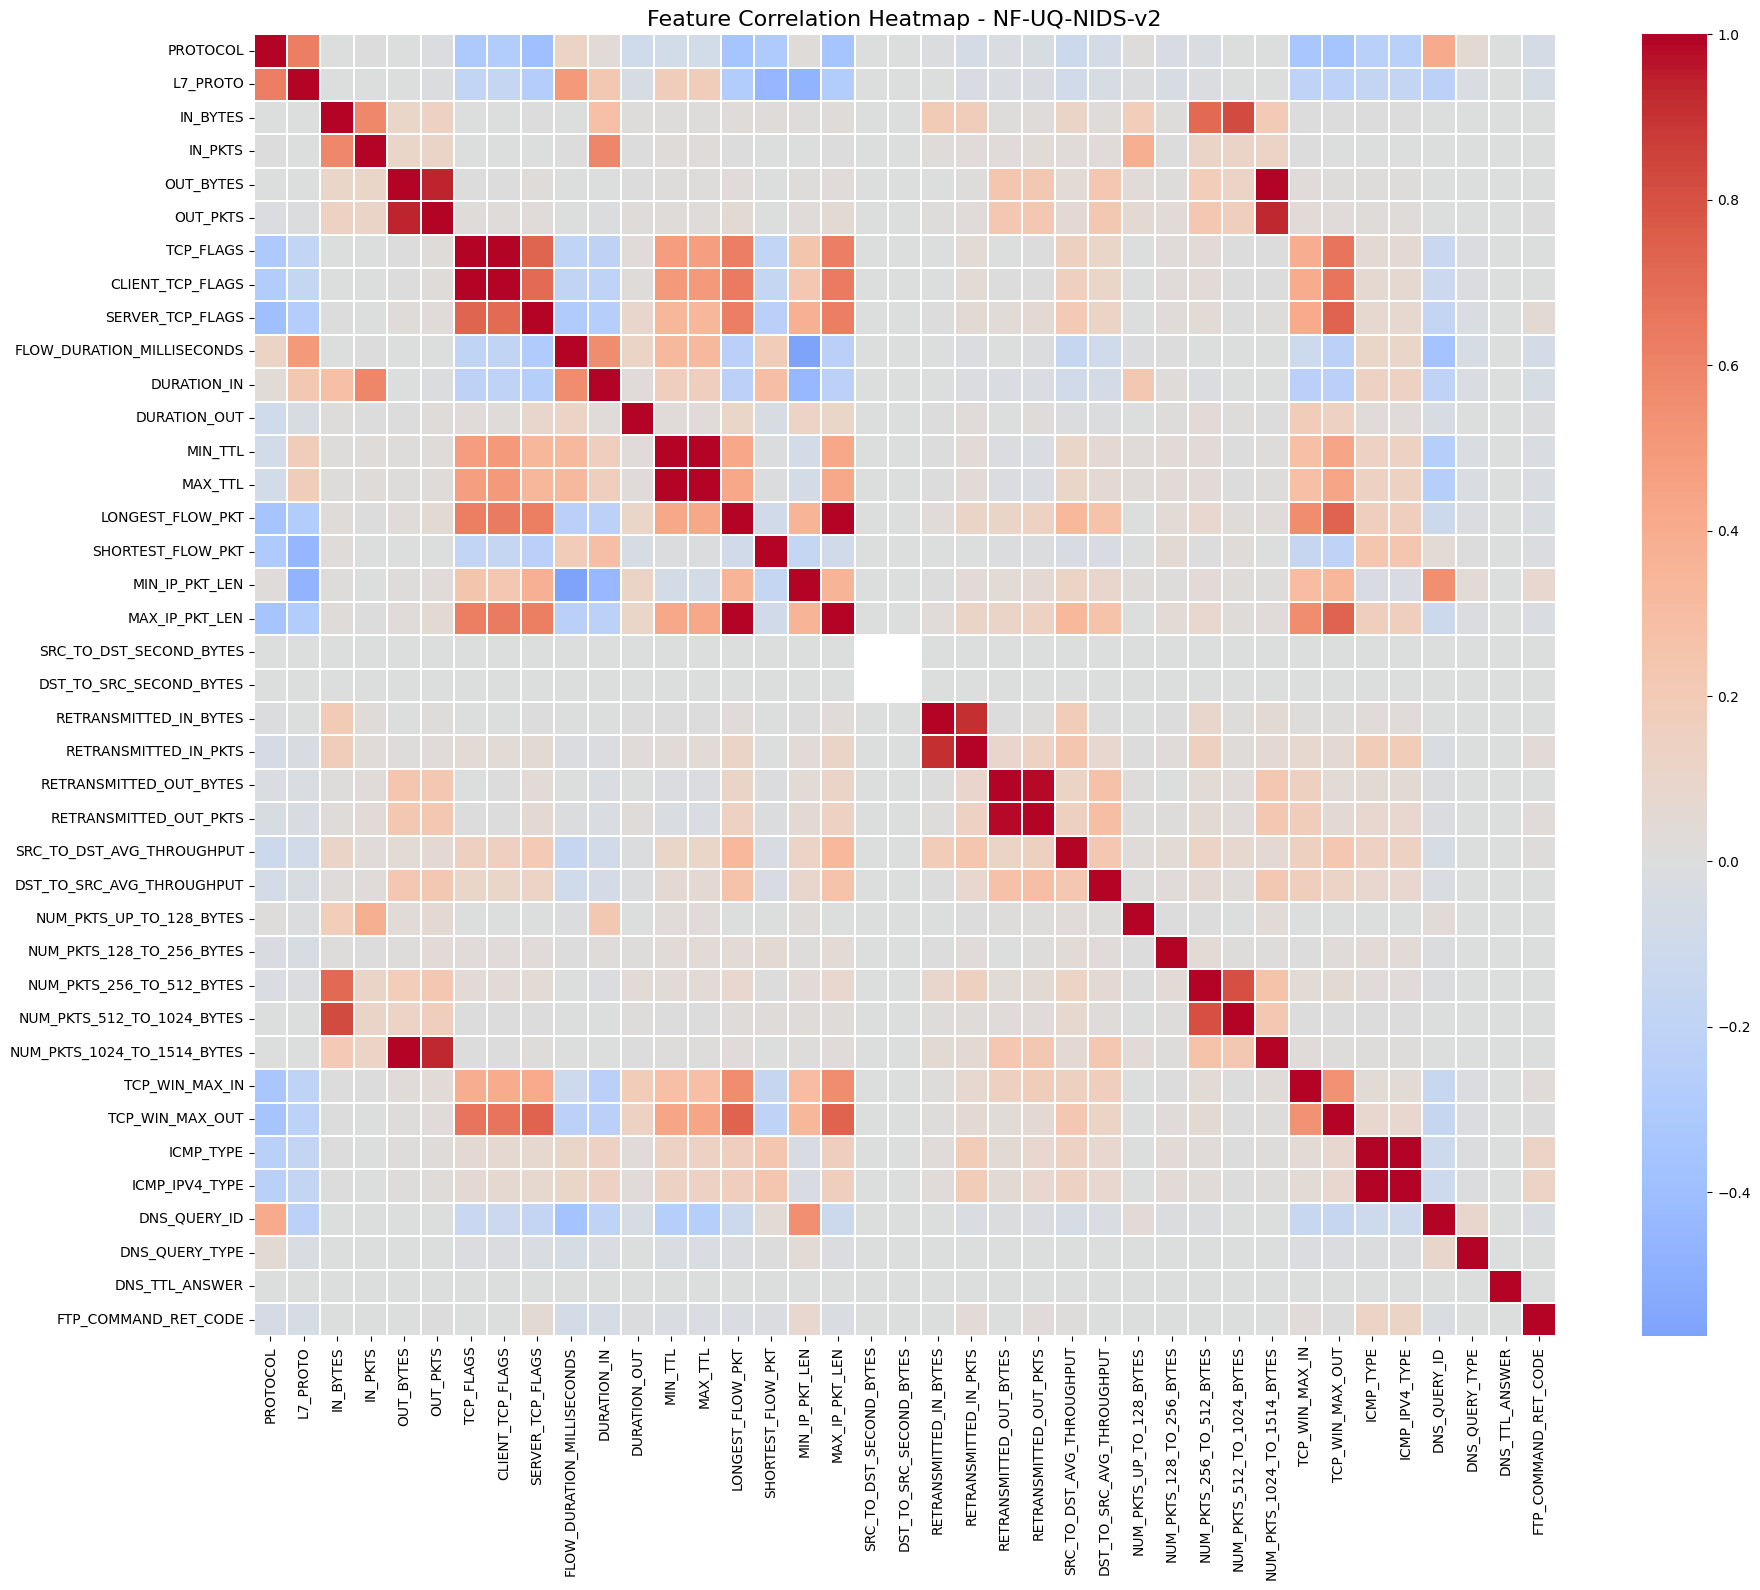

In [5]:

# Correlation matrix of features
corr = X.corr()
#red = positive and blue = negetive
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False,    
    linewidths=0.2,
    square=True
)
plt.title('Feature Correlation Heatmap - NF-UQ-NIDS-v2', fontsize=16)
plt.tight_layout()
plt.savefig('dataset_heatmap.png', dpi=150)
plt.show()

In [6]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 838860
Testing set size: 209715


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     69438
           1       1.00      0.97      0.98    140277

    accuracy                           0.98    209715
   macro avg       0.97      0.98      0.98    209715
weighted avg       0.98      0.98      0.98    209715



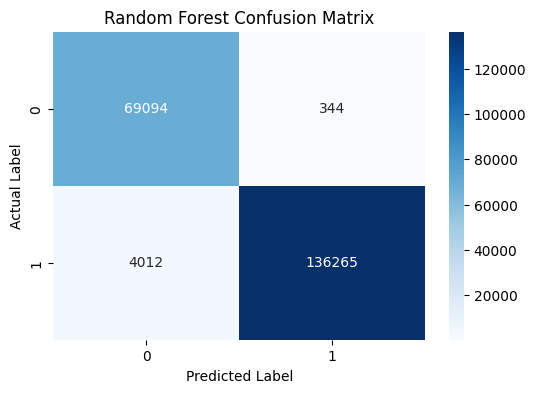

In [7]:
# Step 5: Train & Evaluate Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1,class_weight='balanced')
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
#Learning Curve: Random Forest 

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
#cv = cross validation
train_sizes, train_scores, val_scores = learning_curve(
    estimator  = rf_model,
    X          = X_train,
    y          = y_train,
    cv         = 3,                         
    scoring    = 'accuracy',
    train_sizes= np.linspace(0.1, 1.0, 5),  
    n_jobs     = -1                          
)

# Calculate mean accuracy at each point
train_mean = np.mean(train_scores, axis=1) #accuracy on trainning data
val_mean   = np.mean(val_scores,   axis=1) #accuracy on unseen validation data

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue',   label='Training Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='orange', label='Validation Accuracy')
plt.title('Learning Curve — Random Forest')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_rf.png', dpi=150)
plt.show()

KeyboardInterrupt: 

In [ ]:
import joblib
model_filename = 'random_forest_model.joblib'
joblib.dump(rf_model, model_filename)

print(f"Random Forest model saved successfully to {model_filename}")

Random Forest model saved successfully to random_forest_model.joblib


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     69438
           1       1.00      0.97      0.98    140277

    accuracy                           0.98    209715
   macro avg       0.97      0.98      0.98    209715
weighted avg       0.98      0.98      0.98    209715



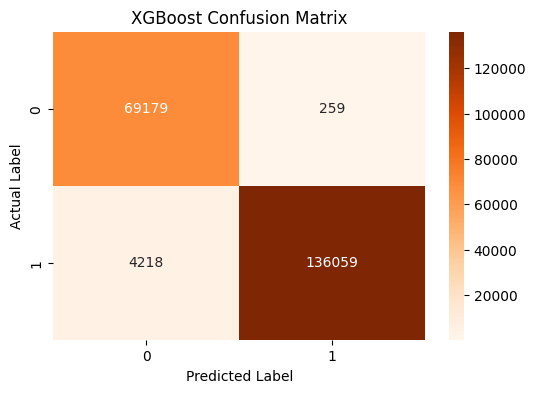

In [ ]:
# Step 6: Train & Evaluate XGBoost
xgboost_weight = sum(y_train == 0) / sum(y_train == 1)

xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42,scale_pos_weight=xgboost_weight)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print("XGBoost Classification Report:")  
print(classification_report(y_test, xgb_predictions))

# Confusion Matrix for XGBoost
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, xgb_predictions), annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

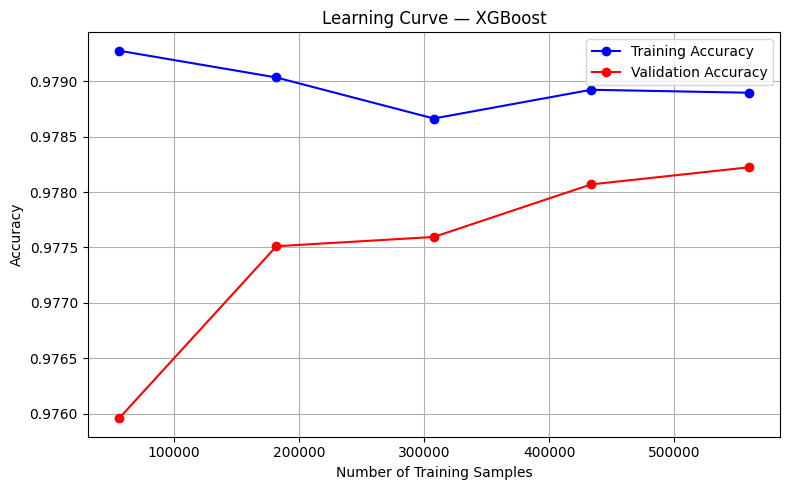

In [ ]:
# ── Learning Curve: XGBoost
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = xgb_model,
    X           = X_train,
    y           = y_train,
    cv          = 3,
    scoring     = 'accuracy',
    train_sizes = np.linspace(0.1, 1.0, 5),
    n_jobs      = -1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores,   axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue',   label='Training Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='red',    label='Validation Accuracy')
plt.title('Learning Curve — XGBoost')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_xgb.png', dpi=150)
plt.show()

In [ ]:
#saving the xgboost_model
import joblib

joblib.dump(xgb_model, r"I:\Datasets\IDS Projects\xgb_model.joblib")
print("XGBoost model saved.")

XGBoost model saved.


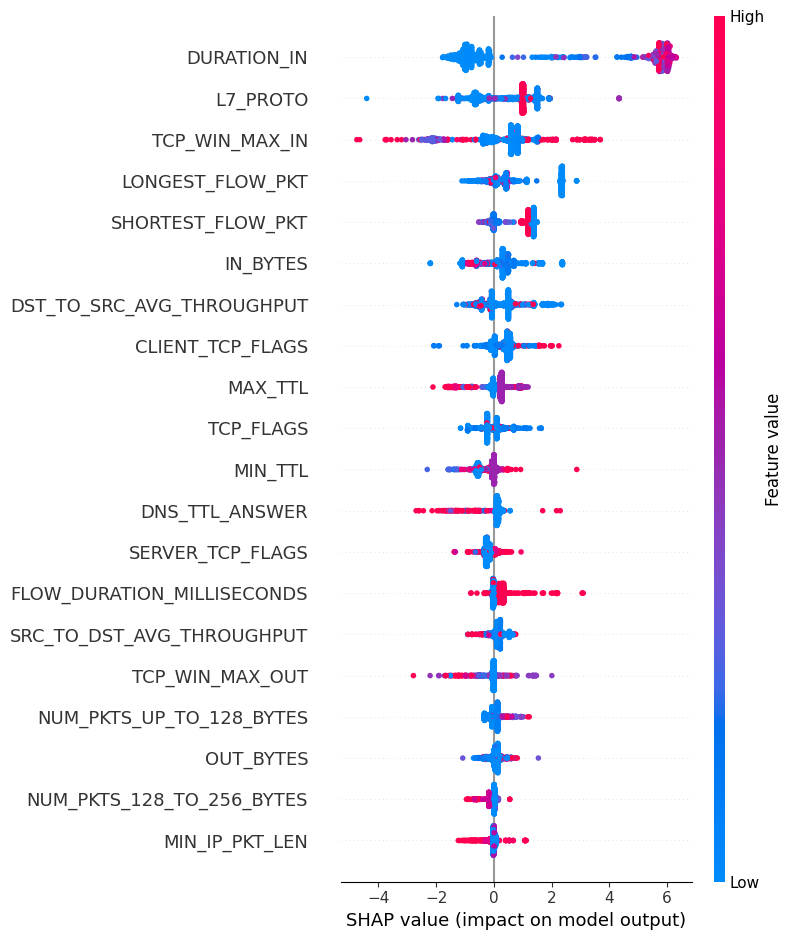

In [ ]:
# Step 7: SHAP Explainability (XGBoost Only)
X_shap = X_test.sample(n=min(1000, X_test.shape[0]), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap) #contribution score

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_shap, feature_names=X_shap.columns)

In [ ]:
import lightgbm as lgb
model = lgb.LGBMClassifier(random_state=42,class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 561049, number of negative: 277811
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5910
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     69438
           1       1.00      0.97      0.98    140277

    accuracy                           0.98    209715
   macro avg       0.97      0.98      0.97    209715
weighted avg       0.98      0.98      0.98    209715



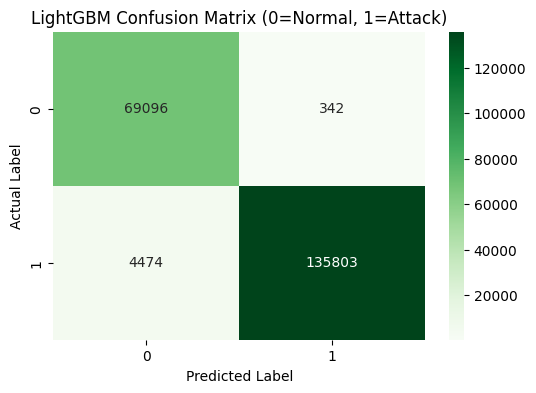

In [ ]:
# Predict using the trained LightGBM model
lgb_predictions = model.predict(X_test)

print("LightGBM Classification Report:")
print(classification_report(y_test, lgb_predictions))

# Plot the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lgb_predictions), annot=True, fmt='d', cmap='Greens')
plt.title('LightGBM Confusion Matrix (0=Normal, 1=Attack)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


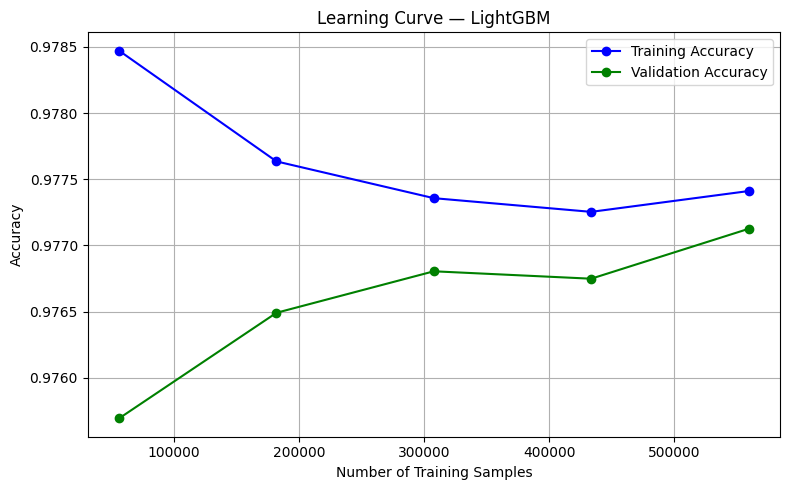

In [ ]:
# Learning Curve: LightGBM 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = model,              
    X           = X_train,
    y           = y_train,
    cv          = 3,
    scoring     = 'accuracy',
    train_sizes = np.linspace(0.1, 1.0, 5),
    n_jobs      = -1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores,   axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue',  label='Training Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='green', label='Validation Accuracy')
plt.title('Learning Curve — LightGBM')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_lgb.png', dpi=150)
plt.show()

In [ ]:
import joblib
joblib.dump(model, 'lgb_model.joblib')
print("LightGBM model saved.")


LightGBM model saved.


Data Counts for each Label:
Label
1    701326
0    347249
Name: count, dtype: int64

Data Percentages for each Label:
Label
1    66.883723
0    33.116277
Name: proportion, dtype: float64


C:\Users\akash\AppData\Local\Temp\ipykernel_15072\3652299039.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Label', palette='Set2')


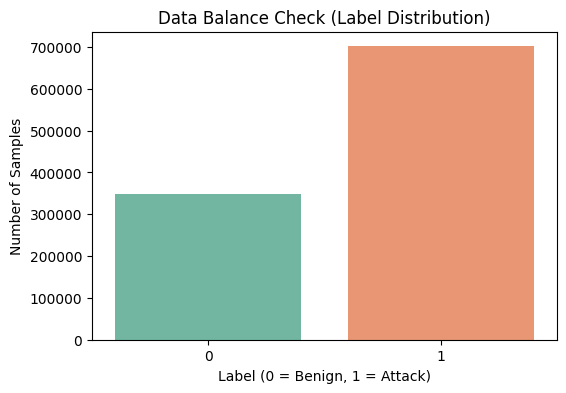

In [ ]:
# 1. Print the exact counts of each class (0 = Benign, 1 = Attack)
print("Data Counts for each Label:")
print(df_cleaned['Label'].value_counts())

# 2. Print the percentage of the dataset that belongs to each class
print("\nData Percentages for each Label:")
print(df_cleaned['Label'].value_counts(normalize=True) * 100)

# 3. Visually plot the balance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='Label', palette='Set2')
plt.title('Data Balance Check (Label Distribution)')
plt.xlabel('Label (0 = Benign, 1 = Attack)')
plt.ylabel('Number of Samples')
plt.show()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

svm_model = Pipeline([
    # 1. Scale everything to [-1, 1] to prevent massive outlier explosions
    ('scaler', MinMaxScaler(feature_range=(-1, 1))),
    
    # 2. Use RBF kernel with default gamma (1 / n_features)
    ('nystroem', Nystroem(
        kernel='rbf', 
        gamma=None,  # Sklearn will automatically set this to 1/40
        n_components=1200, # Max components for maximum boundary precision
        random_state=42
    )),
    
    # 3. SGDClassifier with class_weight='balanced'
    ('svm', SGDClassifier(
        loss='hinge',
        penalty='l2',
        alpha=1e-5,
        max_iter=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

svm_model.fit(X_train, y_train)

# After svm_model.fit() and svm_predictions — add this:

scores = svm_model.decision_function(X_test)

# Try threshold = -0.3 to push Attack recall higher
threshold = -0.3
preds_tuned = (scores >= threshold).astype(int)
print(f"Threshold = {threshold}:")
print(classification_report(y_test, preds_tuned))

svm_predictions = svm_model.predict(X_test)

print("SVM Classification Report:")
print(classification_report(y_test, svm_predictions))
print("n_iter:", svm_model.named_steps['svm'].n_iter_)

Threshold = -0.3:
              precision    recall  f1-score   support

           0       0.75      0.95      0.83     69438
           1       0.97      0.84      0.90    140277

    accuracy                           0.88    209715
   macro avg       0.86      0.89      0.87    209715
weighted avg       0.90      0.88      0.88    209715

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.96      0.83     69438
           1       0.97      0.83      0.90    140277

    accuracy                           0.87    209715
   macro avg       0.86      0.89      0.86    209715
weighted avg       0.90      0.87      0.88    209715

n_iter: 11


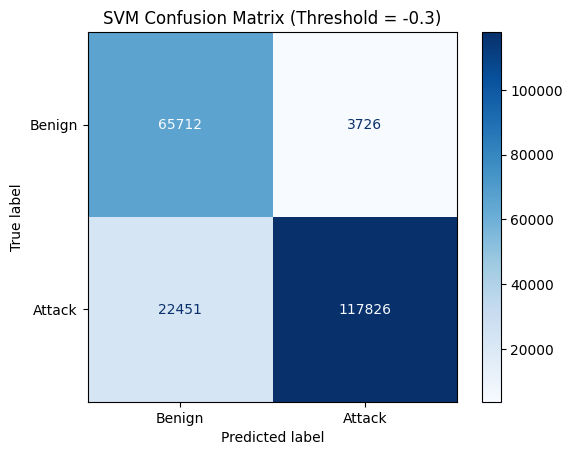

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

scores = svm_model.decision_function(X_test)
preds_tuned = (scores >= -0.3).astype(int)

cm = confusion_matrix(y_test, preds_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues')
plt.title('SVM Confusion Matrix (Threshold = -0.3)')
plt.show()


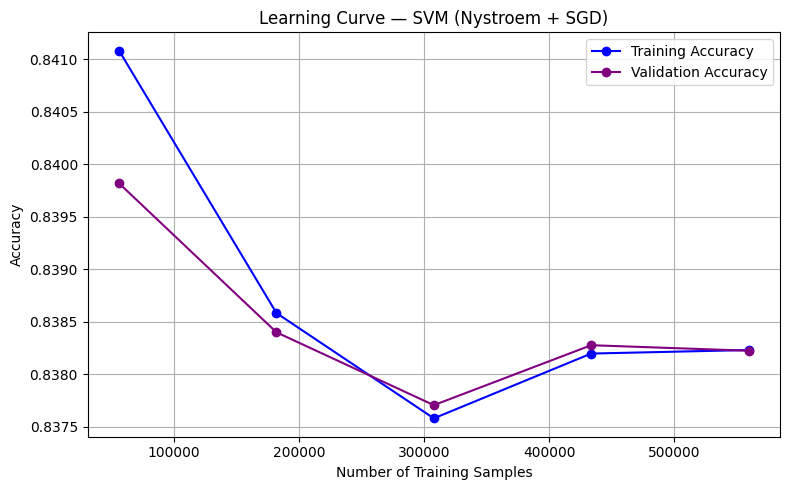

In [ ]:
# ── Learning Curve: SVM (Nystroem + SGD) ──────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier

# Rebuild SVM pipeline with lower n_components to avoid memory error
svm_lc_model = Pipeline([
    ('scaler',   MinMaxScaler(feature_range=(-1, 1))),
    ('nystroem', Nystroem(kernel='rbf', n_components=300, random_state=42)),
    ('svm',      SGDClassifier(loss='hinge', penalty='l2', class_weight='balanced', random_state=42))
])

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = svm_lc_model,
    X           = X_train,
    y           = y_train,
    cv          = 3,
    scoring     = 'accuracy',
    train_sizes = np.linspace(0.1, 1.0, 5),
    n_jobs      = -1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores,   axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue',   label='Training Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='purple', label='Validation Accuracy')
plt.title('Learning Curve — SVM (Nystroem + SGD)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_svm.png', dpi=150)
plt.show()

In [ ]:
import joblib
joblib.dump(svm_model, 'svm_model.joblib')
print("SVM model saved.")

SVM model saved.


In [ ]:
print(X_train.columns.tolist())
print(len(X_train.columns)) 

['PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE']
39


In [ ]:
#first chunk
import pandas as pd

test_data = pd.read_csv(
    r"I:\Datasets\IDS Projects\Datset original\9810e03bba4983da_MOHANAD_A4706\data\NF-UQ-NIDS-v2.csv",
    skiprows=range(1, 1000001),  # skip first 10 lakh rows (already used for training)
    nrows=200000                  # load next 2 lakh rows for testing
)

print(test_data.shape)
print(test_data['Label'].value_counts())  # check attack vs benign distribution

(200000, 46)
Label
1    133916
0     66084
Name: count, dtype: int64


In [ ]:
test_data.to_csv(
    r"I:\Datasets\IDS Projects\SET 2\data\rest_data_test.csv",
    index=False
)
print("Test data saved successfully!")

Test data saved successfully!


In [ ]:
feature_columns = ['PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 
                   'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 
                   'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 
                   'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 
                   'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 
                   'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 
                   'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 
                   'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 
                   'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 
                   'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE']

X_test = test_data[feature_columns]
y_test = test_data['Label']

print(X_test.shape)
print(y_test.shape)

(200000, 39)
(200000,)


In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.31883

Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.59      0.36     66084
           1       0.48      0.19      0.27    133916

    accuracy                           0.32    200000
   macro avg       0.37      0.39      0.32    200000
weighted avg       0.41      0.32      0.30    200000



In [ ]:
# Scale the test data using the SAME scaler from training
X_test_scaled = scaler.transform(X_test)
X_test_scaled = np.clip(X_test_scaled, -1e30, 1e30)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)
X_test_scaled = X_test_scaled.astype(np.float32)

print("Test data scaled successfully!", X_test_scaled.shape)

Test data scaled successfully! (200000, 39)


In [ ]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

C:\Users\akash\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.976645

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     66084
           1       1.00      0.97      0.98    133916

    accuracy                           0.98    200000
   macro avg       0.97      0.98      0.97    200000
weighted avg       0.98      0.98      0.98    200000



In [ ]:
joblib.dump(scaler, r"I:\Datasets\IDS Projects\SET 2\data\scaler.joblib")
print("Scaler saved!")

Scaler saved!
